# Import Modules

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


# Data Loading and Hybrid Feature Extraction

In [104]:
def extract_hybrid_features(file_path, max_pad_len=128):
    try:
        # Load audio with NO offset to avoid skipping short clips
        y, sr = librosa.load(file_path, duration=3)

        # Pad short audio to at least 0.5 seconds
        # This ensures we always have enough frames for Delta/Delta-Delta
        min_samples = int(sr * 0.5) 
        if len(y) < min_samples:
            y = np.pad(y, (0, min_samples - len(y)), mode='constant')
        
        # Normalize audio
        y = librosa.util.normalize(y)
    
        # 1. MFCC - 20
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    
        # Delta MFCC - 20
        mfcc_delta = librosa.feature.delta(mfcc)
    
        # Delta-Delta MFCC - 20
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
    
        # 2. Chroma - 12
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    
        # 3. RMS Energy - 1
        rms = librosa.feature.rms(y=y)
    
        # 4. Spectral Features - 3
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    
        # 5. Zero Crossing Rate - 1
        zcr = librosa.feature.zero_crossing_rate(y)
    
        # Combine All Features - 77
        combined = np.vstack([
            mfcc,
            mfcc_delta,
            mfcc_delta2,
            chroma,
            rms,
            centroid,
            bandwidth,
            rolloff,
            zcr
        ])

        # Padding / Truncation
        if combined.shape[1] < max_pad_len:
            pad_width = max_pad_len - combined.shape[1]
            combined = np.pad(combined, ((0,0),(0,pad_width)), mode='constant')
        else:
            combined = combined[:, :max_pad_len]
    
        return combined.T
        
    except Exception as e:
        print(f"Error for {file_path}: {type(e).__name__} - {e}")
        return None


def makeThePlot(Y):
    df = pd.DataFrame({'emotion': Y})
    
    # Set the visual style
    plt.figure(figsize=(10, 5))
    sns.set_style("whitegrid")
    
    # Create the distribution chart
    ax = sns.countplot(x='emotion', data=df, palette='viridis', order=df['emotion'].value_counts().index)
    
    # Add titles and labels
    plt.title('Distribution of Emotions in Dataset', fontsize=15)
    plt.xlabel('Emotion Category', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45) # Rotates labels for better readability
    
    # Show the plot
    plt.show()

Extracting hybrid features from 7442 CREMA-D files...


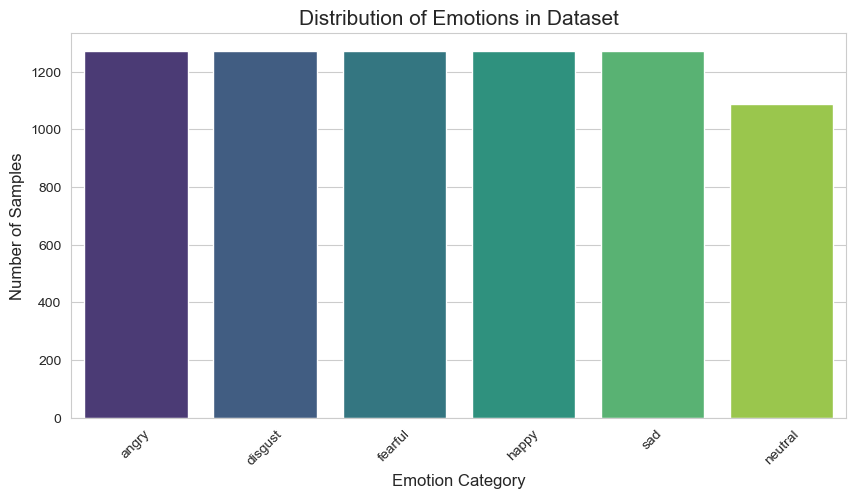

In [95]:
# CREMA-D emotion mapping
CREMAD_MAP = {'ANG':'angry', 'DIS':'disgust', 'FEA':'fearful', 'HAP':'happy', 
              'NEU':'neutral', 'SAD':'sad'}
Y_cremad = []
def load_cremad_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} CREMA-D files...")

    for file in file_list:
        # Filename example: 1001_DFA_ANG_XX.wav
        # Split by '_' and take the 3rd element (index 2)
        code = os.path.basename(file).split('_')[2]
        emotion = CREMAD_MAP.get(code)
        if emotion:
            X.append(extract_hybrid_features(file))
            y.append(emotion)
            Y_cremad.append(emotion)
            
    return np.array(X), np.array(y)

CREMAD_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\CREMA-D\AudioWAV"
X_cremad, y_cremad = load_cremad_data(CREMAD_PATH)


# 6 emotions : angry, fearful, disgust, sad, happy, neutral
makeThePlot(Y_cremad)

Extracting hybrid features from 535 EMO-DB files...


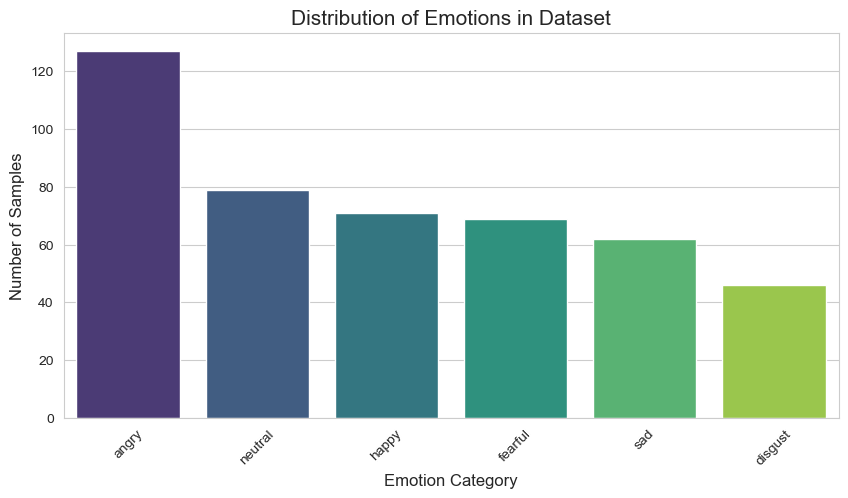

In [94]:
# EMO-DB emotion mapping
# W:Wut (angry), L:Langeweile (boredom), E:Ekel (disgust), A:Angst (fearful), 
# F:Freude (happy), T:Trauer (sad), N:Neutral (neutral)
EMODB_MAP = {'W':'angry', 'L':'boredom', 'E':'disgust', 'A':'fearful', 
             'F':'happy', 'T':'sad', 'N':'neutral'}

Y_emodb = []
def load_emodb_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} EMO-DB files...")

    for file in file_list:
        fname = os.path.basename(file)
        # The 6th character (index 5) represents the emotion
        code = fname[5]
        emotion = EMODB_MAP.get(code)
        if emotion == 'boredom': # skipping the feature with least counts
            continue
        if emotion:
            X.append(extract_hybrid_features(file))
            y.append(emotion)
            Y_emodb.append(emotion)
            
    return np.array(X), np.array(y)

EMODB_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\EMO-DB\wav"
X_emodb, y_emodb = load_emodb_data(EMODB_PATH)


# 7 emotions : angry, boredom, disgust, fearful, happy, sad, neutral
makeThePlot(Y_emodb)

Extracting hybrid features from 35000 ESD files...


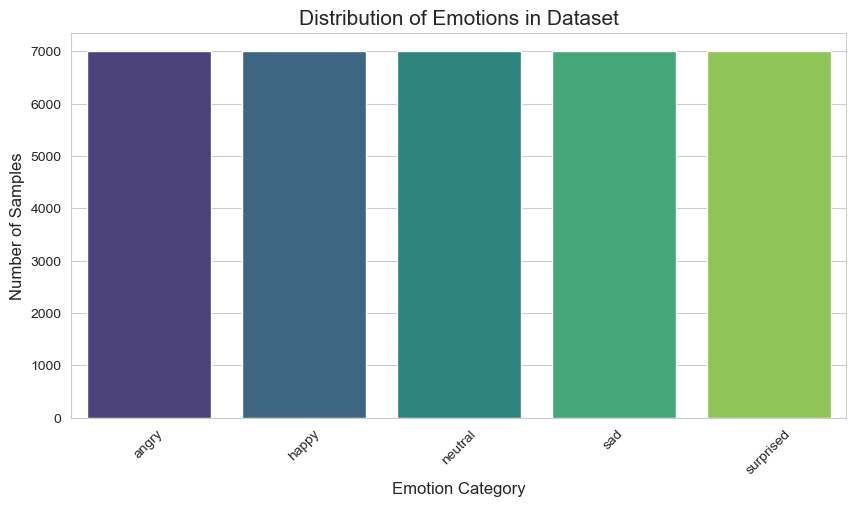

In [93]:
# ESD emotion mapping
# ESD has folders: 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise'
ESD_MAP = {
    'angry': 'angry', 
    'happy': 'happy', 
    'neutral': 'neutral', 
    'sad': 'sad', 
    'surprise': 'surprised'
}

Y_esd = []
def load_esd_data(data_path):
    X, y = [], []
    # This glob pattern goes into: Speaker Folders (0001) -> Emotion Folders (Angry) -> .wav
    file_list = glob.glob(os.path.join(data_path, "*", "*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} ESD files...")

    for file in file_list:
        folder_name = os.path.basename(os.path.dirname(file)).lower()
        emotion = ESD_MAP.get(folder_name)
        if emotion:
            X.append(extract_hybrid_features(file))
            y.append(emotion)
            Y_esd.append(emotion)
            
    return np.array(X), np.array(y)

ESD_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\ESD\Emotion Speech Dataset"
X_esd, y_esd = load_esd_data(ESD_PATH)


# 5 emotions : angry, surprised, happy, sad, neutral

makeThePlot(Y_esd)

Extracting hybrid features from 3200 HINDI files...


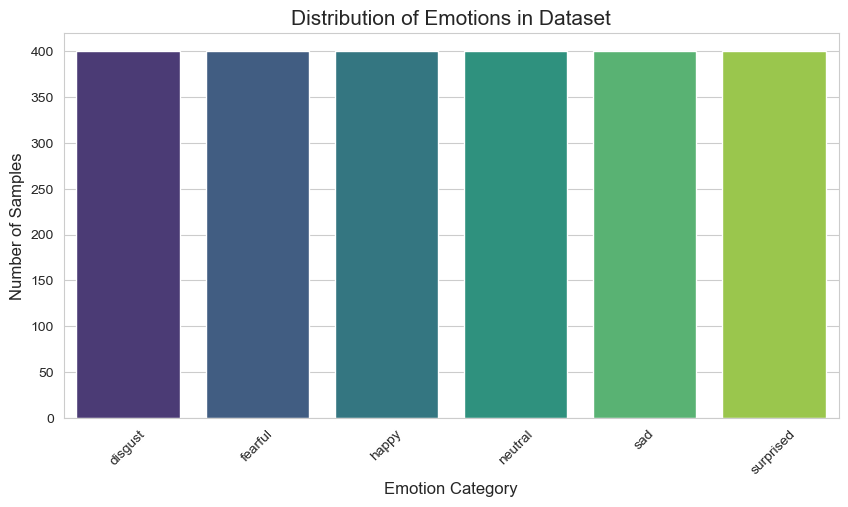

In [92]:
# Mapping to your standard labels
HINDI_MAP = {
    'neutral': 'neutral',
    'happy': 'happy',
    'sad': 'sad',
    'angry': 'angry',
    'fear': 'fearful',
    'disgust': 'disgust',
    'surprise': 'surprised',
    'sarcastic': 'sarcastic'
}

Y_hindi = []
def load_hindi_data(data_path):
    X, y = [], []
    # This pattern goes into: Speaker (6) -> Session (session1) -> Emotion (neutral) -> *.wav
    file_list = glob.glob(os.path.join(data_path, "*", "*", "*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} HINDI files...")

    for file in file_list:
        folder_name = os.path.basename(os.path.dirname(file)).lower()
        emotion = HINDI_MAP.get(folder_name)
        if emotion == 'sarcastic': # skipping the feature with least counts
            continue
        if emotion:
            X.append(extract_hybrid_features(file))
            y.append(emotion)
            Y_hindi.append(emotion)
            
    return np.array(X), np.array(y)

HINDI_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\HINDI\my Dataset"
X_hindi, y_hindi = load_hindi_data(HINDI_PATH)


# 8 emotions : angry, surprised, sarcastic, disgust, fearful, happy, sad, neutral

makeThePlot(Y_hindi)

Extracting hybrid features from 2400 JL Corpus files...


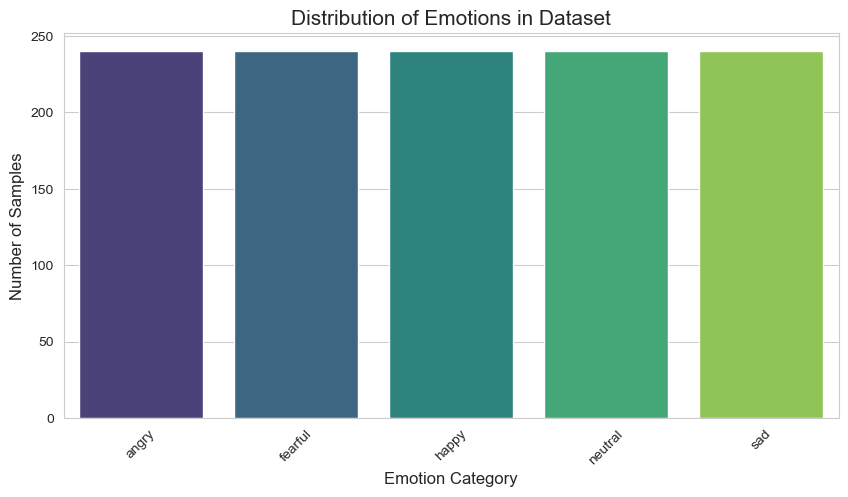

In [91]:
# JL Corpus specific mapping
JL_MAP = {
    'angry': 'angry',
    'anxious': 'fearful',
    'apologetic': 'apologetic',
    'assertive': 'assertive',
    'concerned': 'concerned',
    'encouraging': 'encouraging',
    'excited': 'excited',
    'happy': 'happy',
    'neutral': 'neutral',
    'sad': 'sad'
}

Y_jl = []
def load_jl_corpus_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} JL Corpus files...")

    for file in file_list:
        fname = os.path.basename(file)
        # female1_angry_2a_1.wav -> parts[1] is 'angry'
        parts = fname.split('_')
        
        if len(parts) > 1:
            code = parts[1].lower()
            emotion = JL_MAP.get(code)
            if emotion in ['apologetic', 'assertive', 'concerned', 'encouraging', 'excited']: # skipping the feature with least counts
                continue
            if emotion:
                X.append(extract_hybrid_features(file))
                y.append(emotion)
                Y_jl.append(emotion)
            
    return np.array(X), np.array(y)

JL_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\JL Corpus\Raw JL corpus (unchecked and unannotated)\JL(wav+txt)"
X_jl, y_jl = load_jl_corpus_data(JL_PATH)


# 10 emotions : angry, anxious, apologetic, assertive, concerned, encouraging, excited, happy, neutral, sad

makeThePlot(Y_jl)

Extracting hybrid features from 1440 RAVDESS files...


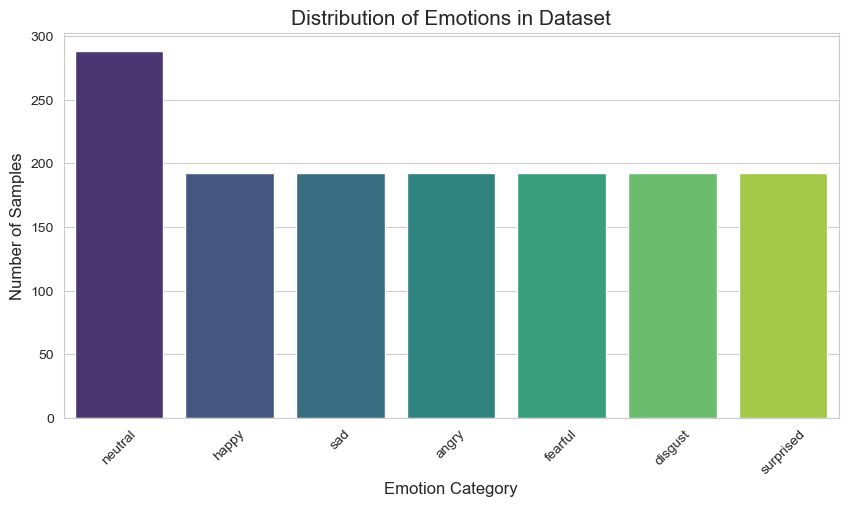

In [89]:
# Full RAVDESS emotion mapping
RAVDESS_MAP = {'01':'neutral', '02':'neutral', '03':'happy', '04':'sad', 
               '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'}

Y_ravdess = []
def load_ravdess_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "Actor_*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} RAVDESS files...")

    for file in file_list:
        emotion = RAVDESS_MAP[os.path.basename(file).split('-')[2]]
        X.append(extract_hybrid_features(file))
        y.append(emotion)
        Y_ravdess.append(emotion)
            
    return np.array(X), np.array(y)
    
DATA_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\RAVDESS"
X_ravdess, y_ravdess = load_ravdess_data(DATA_PATH)


# 8 emotions : neutral, calm, happy, sad, angry, fearful, disgust, surprised

makeThePlot(Y_ravdess)

Extracting hybrid features from 480 SAVEE files...


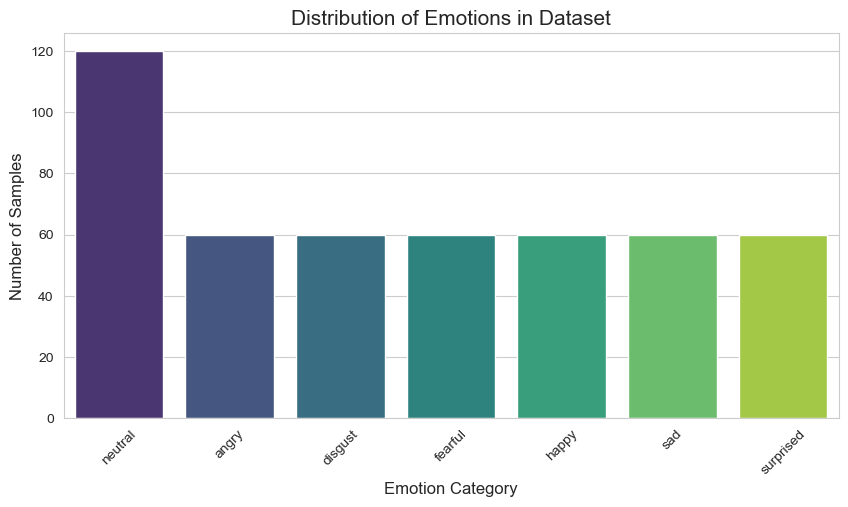

In [56]:
# SAVEE emotion mapping
SAVEE_MAP = {
    'a': 'angry', 
    'd': 'disgust', 
    'f': 'fearful', 
    'h': 'happy', 
    'n': 'neutral', 
    'sa': 'sad', 
    'su': 'surprised'
}

Y_savee = []
def load_savee_data(data_path):
    X, y = [], []
    file_list = os.listdir(data_path)
    print(f"Extracting hybrid features from {len(file_list)} SAVEE files...")

    for audio_file in file_list:
        try:
            part = audio_file.split('_')[1]
            code = part[:-6] 
            emotion = SAVEE_MAP.get(code)
            
            if emotion:
                full_path = os.path.join(data_path, audio_file)
                features = extract_hybrid_features(full_path)
                if features is not None:
                    X.append(features)
                    y.append(emotion)
                    Y_savee.append(emotion)
                    
        except Exception as e:
            continue
            
    return np.array(X), np.array(y)


SAVEE_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\SAVEE\ALL"
X_savee, y_savee = load_savee_data(SAVEE_PATH)


# 7 emotions : angry, fearful, disgust, sad, happy, surprised, neutral

makeThePlot(Y_savee)

Extracting hybrid features from 2800 TESS files...


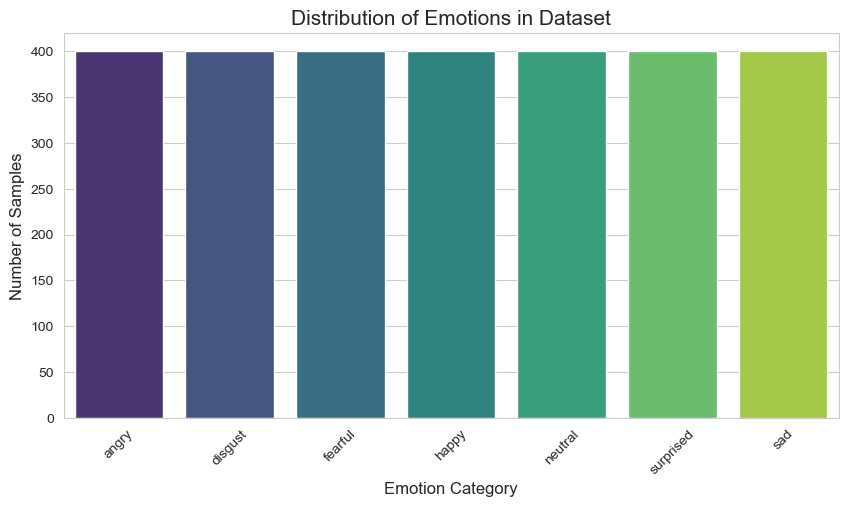

In [57]:
Y_tess = []
def load_tess_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} TESS files...")

    for file in file_list:
        # Get filename (e.g., 'OAF_back_angry.wav')
        fname = os.path.basename(file)
        emotion = fname.split('_')[-1].split('.')[0].lower()
        if emotion == 'ps':
            emotion = 'surprised'
        if emotion == 'fear':
            emotion = 'fearful'
        X.append(extract_hybrid_features(file))
        y.append(emotion)
        Y_tess.append(emotion)
            
    return np.array(X), np.array(y)

TESS_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\TESS\TESS Toronto emotional speech set data"
X_tess, y_tess = load_tess_data(TESS_PATH)


# 7 emotions : angry, fearful, disgust, sad, happy, surprised, neutral

makeThePlot(Y_tess)

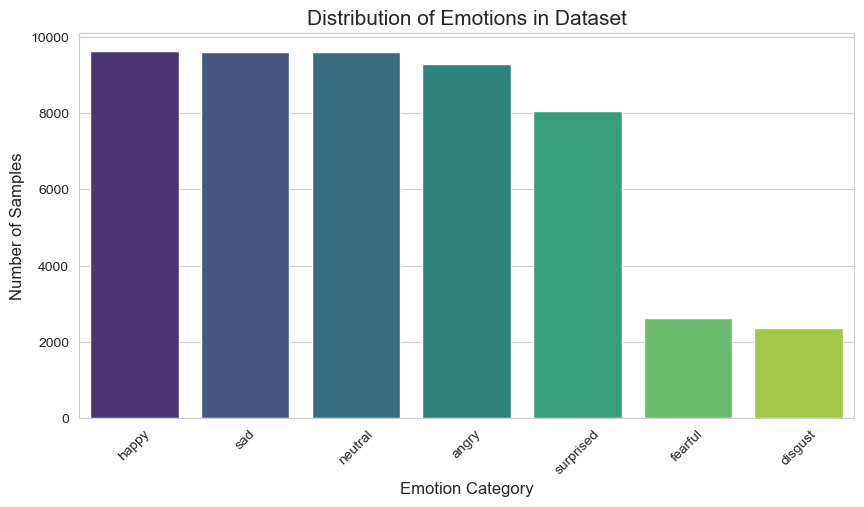

In [84]:
# After balancing the datasets, and dropping the unnecessary emotions. 
# Also not considering the MLEnd dataset (Numerals utterations)

Y_all = np.concatenate([Y_ravdess, Y_tess, Y_savee, Y_cremad, Y_emodb, Y_esd, Y_hindi, Y_jl], axis=0)
makeThePlot(Y_all)

In [96]:
datasets = {
    "RAVDESS": X_ravdess, "TESS": X_tess, "SAVEE": X_savee, 
    "CREMA-D": X_cremad, "EMO-DB": X_emodb, "ESD": X_esd, 
    "HINDI": X_hindi, "JL": X_jl
}

for name, data in datasets.items():
    print(f"{name} shape: {data.shape}")


RAVDESS shape: (1440, 128, 77)
TESS shape: (2800, 128, 77)
SAVEE shape: (480, 128, 77)
CREMA-D shape: (7442, 128, 77)
EMO-DB shape: (454, 128, 77)
ESD shape: (35000, 128, 77)
HINDI shape: (2400, 128, 77)
JL shape: (1200, 128, 77)


In [97]:
# Combine all X and y arrays
X_all = np.concatenate([X_ravdess, X_tess, X_savee, X_cremad, X_emodb, X_esd, X_hindi, X_jl], axis=0)
y_all = np.concatenate([y_ravdess, y_tess, y_savee, y_cremad, y_emodb, y_esd, y_hindi, y_jl], axis=0)

# Scaling: We flatten to scale, then reshape back to (N, 128, 77)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all.reshape(-1, X_all.shape[-1])).reshape(X_all.shape)

# Convert text to Integers (e.g., 'neutral' -> 0, 'happy' -> 1)
lb = LabelEncoder()
y_integers = lb.fit_transform(y_all) 

# Convert those Integers to One-Hot Matrix (for the Model)
y_final = to_categorical(y_integers)

# Calculate Class Weights using the Integers
# It needs the simple list (y_integers) to count the frequencies
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)

dict_weights = dict(enumerate(weights))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_final, test_size=0.2, random_state=42)

print(f"Data loaded: X_train shape {X_train.shape}, y_train shape {y_train.shape}")

Data loaded: X_train shape (40972, 128, 77), y_train shape (40972, 7)


# Create the Hybrid BiLSTM Model

In [100]:
model = Sequential([
    # Stage 1: Convolutional layers for local spectral patterns
    Conv1D(256, 5, padding='same', activation='relu', input_shape=(128, 77)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    # Stage 2: Recurrent layers for temporal emotional rhythm
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    
    Bidirectional(LSTM(64)),
    Dropout(0.3),

    # Stage 3: Classification head
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(7, activation='softmax')
])

# Training Configuration
opt = Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# Callbacks to maximize accuracy and prevent overfitting
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)


In [101]:
# Training the Model
print("Starting training...")
history = model.fit(X_train, y_train, 
                    epochs=200, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[reduce_lr, early_stop],
                    class_weight=dict_weights
                   )


Starting training...
Epoch 1/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 559s 423ms/step - accuracy: 0.4602 - loss: 1.4413 - val_accuracy: 0.6389 - val_loss: 0.9169 - learning_rate: 5.0000e-04
Epoch 2/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 579s 436ms/step - accuracy: 0.6542 - loss: 0.9236 - val_accuracy: 0.7340 - val_loss: 0.6926 - learning_rate: 5.0000e-04
Epoch 3/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 240s 188ms/step - accuracy: 0.7204 - loss: 0.7570 - val_accuracy: 0.7485 - val_loss: 0.6942 - learning_rate: 5.0000e-04
Epoch 4/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 168s 114ms/step - accuracy: 0.7659 - loss: 0.6460 - val_accuracy: 0.7855 - val_loss: 0.5702 - learning_rate: 5.0000e-04
Epoch 5/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 197s 110ms/step - accuracy: 0.7945 - loss: 0.5731 - val_accuracy: 0.8193 - val_loss: 0.4927 - learning_rate: 5.0000e-04
Epoch 6/200
1281/1281 ━━━━━━━━━━━━━━━━━━━━ 146s 114ms/step - accuracy: 0.8179 - loss: 0.5110 - val_accuracy: 0.8151 - val_loss: 0.5066 - learning_rate: 5.0000e-04
E

In [102]:
# Evaluating the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

print(f"Best Train Accuracy: {max(history.history['accuracy']) * 100:.2f}%")

321/321 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8868 - loss: 0.5737
Test Accuracy: 88.68%
Test Loss: 0.5737
Best Train Accuracy: 99.24%


# Plot the Results

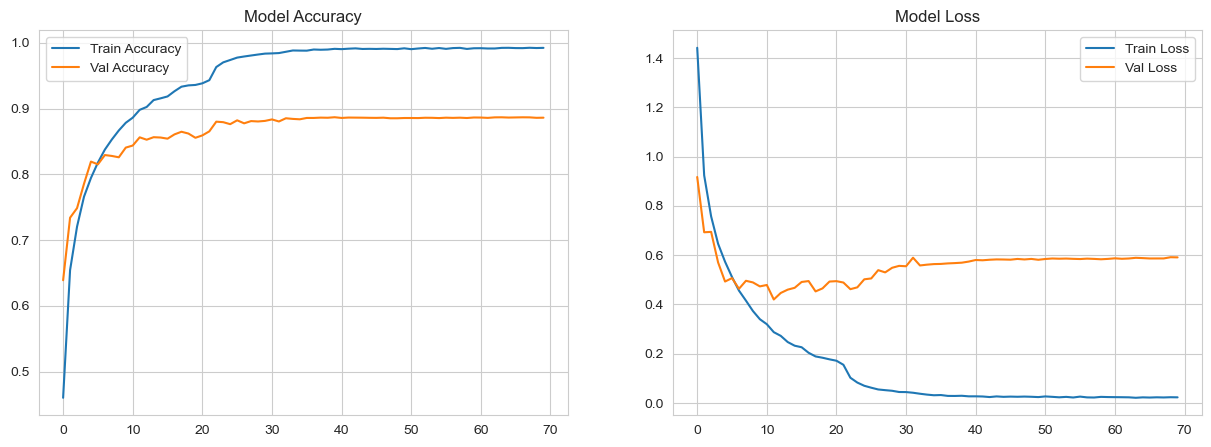

321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step


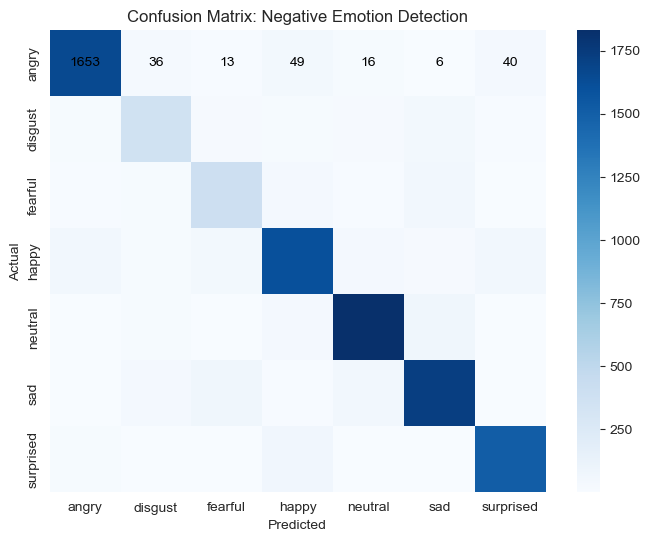


Classification Report:

              precision    recall  f1-score   support

       angry       0.93      0.91      0.92      1813
     disgust       0.73      0.71      0.72       504
     fearful       0.70      0.72      0.71       551
       happy       0.88      0.86      0.87      1868
     neutral       0.92      0.93      0.92      1973
         sad       0.89      0.90      0.89      1917
   surprised       0.93      0.93      0.93      1618

    accuracy                           0.89     10244
   macro avg       0.85      0.85      0.85     10244
weighted avg       0.89      0.89      0.89     10244



In [109]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].legend()
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
cm = cm.astype('int') 
sns.heatmap(np.array(cm), annot=True, fmt='d',annot_kws={"color": "black"}, xticklabels=lb.classes_, yticklabels=lb.classes_, cmap='Blues')
plt.title('Confusion Matrix: Negative Emotion Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=lb.classes_))


In [108]:
print(cm)

[[1653   36   13   49   16    6   40]
 [  21  359   26   17   23   48   10]
 [  15   22  398   42   10   62    2]
 [  64   20   50 1605   41   25   63]
 [   5   17    6   39 1831   73    2]
 [   4   37   73   10   65 1727    1]
 [  20    4    4   69    3    7 1511]]
